# LAB | BMI Survey 


## Part 1: Descriptive Analysis

## Problem Description

Overweight and obesity, measured by Body Mass Index (BMI), are increasing health concerns in Denmark and globally. This project analyzes BMI data from a Danish survey to provide an overview of BMI distributions and investigate potential factors influencing BMI, such as gender, age, and fast food consumption. The analysis aims to summarize and visualize the data using descriptive statistics and graphical methods.

---

## Instructions

- Complete each section below using Python and appropriate libraries (e.g., pandas, numpy, matplotlib, seaborn).
- Provide code, tables, and figures as needed.
- Write brief explanations for your findings after each analysis step.
- Do **not** include code in your final report; code should be submitted separately as an appendix.
- Ensure all figures and tables are clearly labeled and referenced in your explanations.

---

## Q1. Data Overview

**a) Short Description of the Data**

- List all variables in the dataset.
- Classify each variable as quantitative or categorical.
- State the number of observations.
- Check for missing values.


**Instructions:**  
- Summarize the dataset variables and their types.
- Report the number of observations and any missing values.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [10]:
df = pd.read_csv('./data/bmi1_data.csv', delimiter=';')
df.head(5)


,height,weight,gender,urbanity,fastfood
0,180,80,1,5,24.0
1,185,98,1,1,6.0
2,180,80,1,5,6.0
3,168,60,0,4,24.0
4,173,83,1,5,24.0


In [8]:
# Clean column names by stripping quotes
df.columns = df.columns.str.strip('"')
df.head(5)

,height,weight,gender,urbanity,fastfood
0,180,80,1,5,24.0
1,185,98,1,1,6.0
2,180,80,1,5,6.0
3,168,60,0,4,24.0
4,173,83,1,5,24.0


In [11]:
df.columns

Index(['height', 'weight', 'gender', 'urbanity', 'fastfood'], dtype='object')

In [ ]:
## TODO
# Data Overview
print("Variables in the dataset:")
print(df.columns.tolist())

print("\nVariable types:")
print(df.dtypes)

# Classify as quantitative or categorical
quantitative_vars = ['height', 'weight', 'fastfood']  
categorical_vars = ['gender', 'urbanity']
print("\nQuantitative variables:", quantitative_vars)
print("Categorical variables:", categorical_vars)

print("\nNumber of observations:", len(df))

print("\nMissing values per variable:")
print(df.isnull().sum())

Variables in the dataset:
['height', 'weight', 'gender', 'urbanity', 'fastfood']

Variable types:
height        int64
weight        int64
gender        int64
urbanity      int64
fastfood    float64
dtype: object

Quantitative variables: ['height', 'weight', 'fastfood']
Categorical variables: ['gender', 'urbanity']

Number of observations: 145

Missing values per variable:
height      0
weight      0
gender      0
urbanity    0
fastfood    0
dtype: int64


## 2. Calculating BMI

- Compute BMI for each respondent using the formula:

  $$\text{BMI} = \frac{\text{weight (kg)}}{\left[\text{height (m)}\right]^2}$$

- Add BMI as a new column to the dataset.

---


In [ ]:
## TODO
# Calculate BMI
# Convert height from cm to meters
df['height_m'] = df['height'] / 100
df['BMI'] = df['weight'] / (df['height_m'] ** 2)
print("BMI column added. First few rows:")
df[['height', 'weight', 'BMI']].head()

BMI column added. First few rows:


,height,weight,BMI
0,180,80,24.691358
1,185,98,28.634039
2,180,80,24.691358
3,168,60,21.258503
4,173,83,27.732300



## 3. Empirical Distribution of BMI

**b) Density Histogram of BMI Scores**

- Plot a density histogram of BMI.
- Describe the distribution: symmetry, skewness, possible negative values, and variation.

**Instructions:**  
- Comment on the shape and spread of the BMI distribution.

---


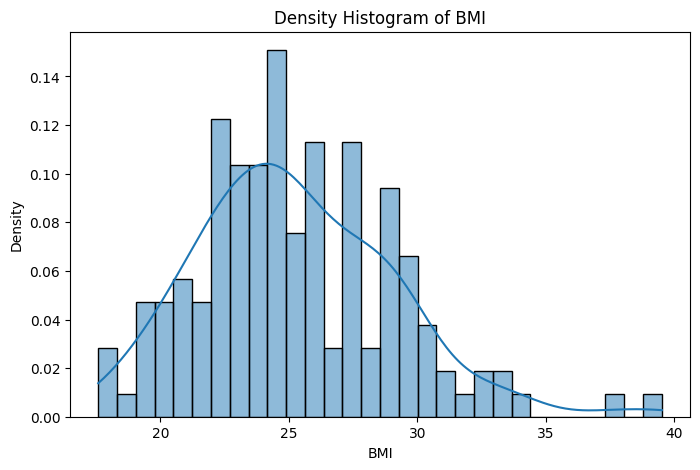

In [14]:
## TODO
# Density histogram of BMI
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], kde=True, stat='density', bins=30)
plt.title('Density Histogram of BMI')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.show()


## 4. Gender Subsets

**c) Separate Density Histograms for Women and Men**

- Create subsets for women and men.
- Plot density histograms for each group.
- Compare and describe the distributions.


**Instructions:**  
- Discuss any gender differences in the BMI distributions.

---


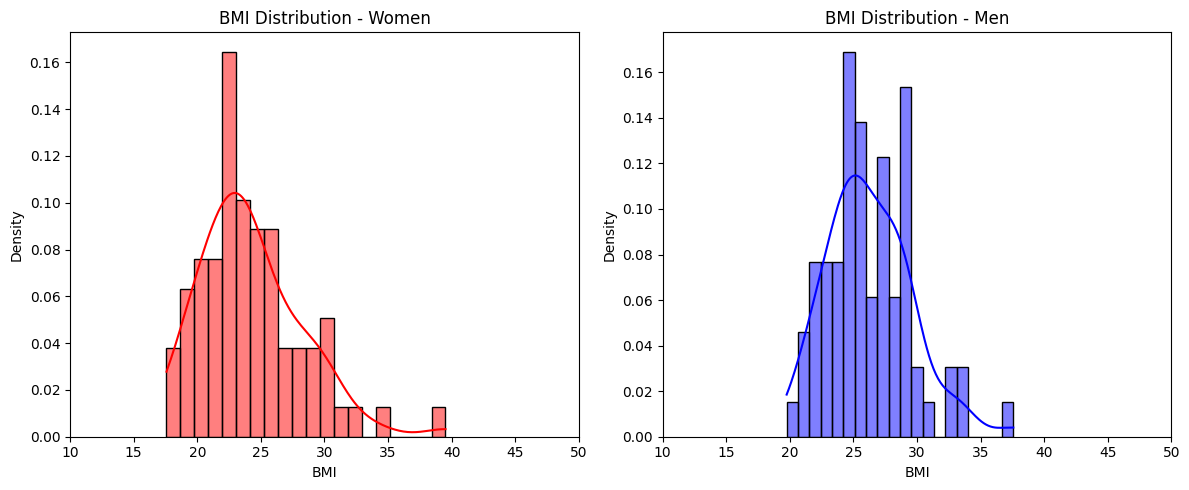

In [15]:
## TODO
# Separate density histograms for women and men
# Assuming gender: 0 = female, 1 = male (based on sample data)
women = df[df['gender'] == 0]
men = df[df['gender'] == 1]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(women['BMI'], kde=True, stat='density', bins=20, color='red')
plt.title('BMI Distribution - Women')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.xlim(10, 50)

plt.subplot(1,2,2)
sns.histplot(men['BMI'], kde=True, stat='density', bins=20, color='blue')
plt.title('BMI Distribution - Men')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.xlim(10, 50)

plt.tight_layout()
plt.show()


## 5. Boxplot by Gender

**d) Box Plot of BMI by Gender**

- Create a box plot of BMI scores grouped by gender.
- Describe the distribution, symmetry/skewness, differences, and outliers.

**Instructions:**  
- Interpret the box plot and compare distributions.

---


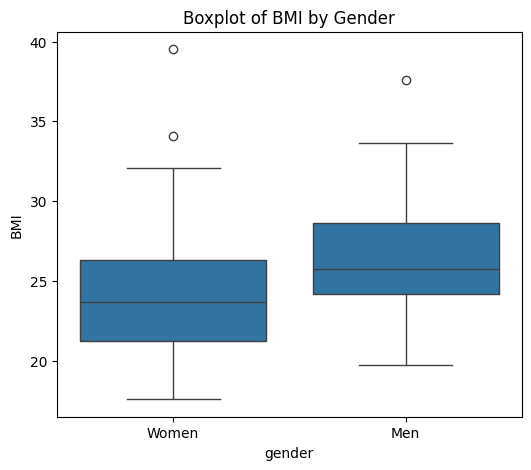

In [16]:
## TODO
# Box plot of BMI by gender
plt.figure(figsize=(6,5))
sns.boxplot(x='gender', y='BMI', data=df)
plt.xticks([0,1], ['Women', 'Men'])
plt.title('Boxplot of BMI by Gender')
plt.ylabel('BMI')
plt.show()

## 6. Summary Statistics

**e) Key Summary Statistics for BMI**

- Calculate and report the following for everyone, women, and men:
  - Number of observations (n)
  - Sample mean (\(\bar{x}\))
  - Sample variance (\(s^2\))
  - Sample standard deviation (\(s\))
  - Lower quartile (Q1)
  - Median (Q2)
  - Upper quartile (Q3)

**Instructions:**  
- Present the summary statistics in a table.
- Discuss what additional insights are provided by the table compared to the box plot.

---


In [17]:
## TODO
# Summary statistics for BMI
def summary_stats(data, group_name):
    stats = {
        'Group': group_name,
        'n': len(data),
        'mean': data.mean(),
        'variance': data.var(),
        'std': data.std(),
        'Q1': data.quantile(0.25),
        'median': data.median(),
        'Q3': data.quantile(0.75)
    }
    return stats

# Overall
overall_stats = summary_stats(df['BMI'], 'All')

# By gender
women_stats = summary_stats(df[df['gender']==0]['BMI'], 'Women')
men_stats = summary_stats(df[df['gender']==1]['BMI'], 'Men')

# Create DataFrame
summary_df = pd.DataFrame([overall_stats, women_stats, men_stats])
summary_df = summary_df.set_index('Group')
print("Summary Statistics for BMI:")
print(summary_df.round(2))

Summary Statistics for BMI:
         n   mean  variance   std     Q1  median     Q3
Group                                                  
All    145  25.25     14.69  3.83  22.59   24.69  27.64
Women   72  24.22     16.42  4.05  21.26   23.69  26.29
Men     73  26.27     11.07  3.33  24.15   25.73  28.63


## Part 2: Missing Values, Outliers, and Bivariate EDA

## 1. Missing Values

- List the number of missing values for each variable in the dataset.
- Choose and apply appropriate strategies for handling missing values (e.g., removal, imputation).
- Justify your chosen approach.
- Show the number of observations before and after handling missing values.

In [ ]:
## TODO
# Missing values
print("Missing values per variable before handling:")
print(df.isnull().sum())

# Check if any missing values exist
if df.isnull().sum().sum() == 0:
    print("No missing values found. No action needed.")
else:
    # If there were missing values, we could impute or drop. But here none.
    pass

# Number of observations before and after (same)
print("Number of observations:", len(df))

Missing values per variable before handling:
height      0
weight      0
gender      0
urbanity    0
fastfood    0
height_m    0
BMI         0
dtype: int64
No missing values found. No action needed.
Number of observations: 145


## 2. Outlier Detection and Handling

### a) Identifying Outliers

- Use visual (boxplots, scatterplots) and statistical methods (e.g., IQR rule, z-scores) to detect outliers in BMI, height, and weight.
- List any extreme values found and discuss whether they are plausible or likely errors.



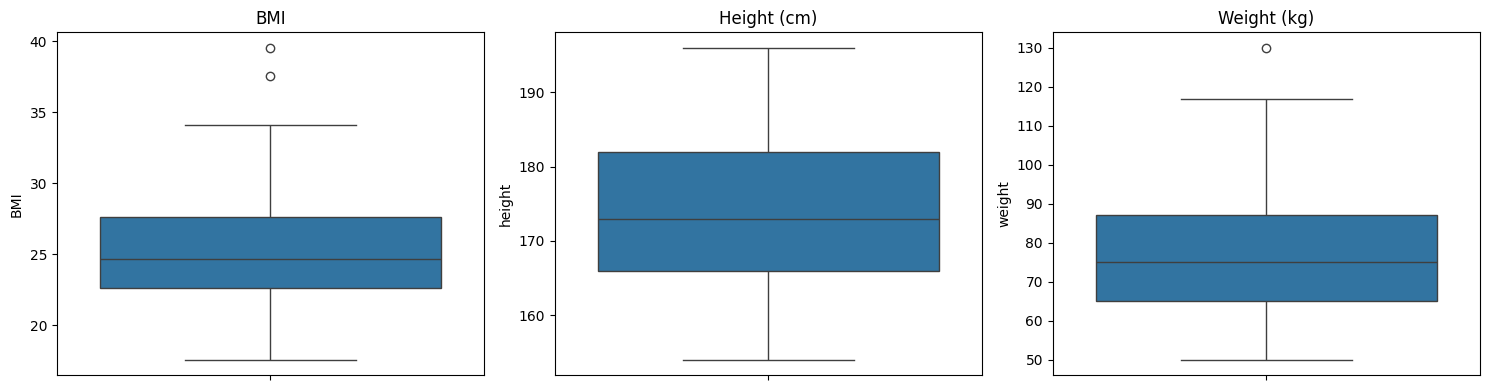


Outliers in BMI:
Bounds: [15.02, 35.21]
Number of outliers: 2
           BMI
73   37.576598
144  39.519741

Outliers in height:
Bounds: [142.00, 206.00]
Number of outliers: 0

Outliers in weight:
Bounds: [32.00, 120.00]
Number of outliers: 1
    weight
73     130


In [19]:
## TODO
# Identify outliers in BMI, height, weight
# Visual methods
fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.boxplot(y=df['BMI'], ax=axes[0]).set_title('BMI')
sns.boxplot(y=df['height'], ax=axes[1]).set_title('Height (cm)')
sns.boxplot(y=df['weight'], ax=axes[2]).set_title('Weight (kg)')
plt.tight_layout()
plt.show()

# Statistical methods: IQR rule
def find_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in ['BMI', 'height', 'weight']:
    outliers, lb, ub = find_outliers_iqr(df, col)
    print(f"\nOutliers in {col}:")
    print(f"Bounds: [{lb:.2f}, {ub:.2f}]")
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(outliers[[col]].sort_values(col))


### b) Handling Outliers

- Decide how to handle detected outliers (e.g., keep, remove, or correct).
- Justify your approach and show the effect on the dataset.



In [20]:
## TODO
# Decide how to handle outliers
# I keep outliers for now, as they may represent real extreme values.

print("Potential extreme values:")
print("BMI > 40:", df[df['BMI'] > 40][['height','weight','BMI']])
print("Weight > 150 kg:", df[df['weight'] > 150][['height','weight','BMI']])
print("Height < 140 cm or > 210 cm:", df[(df['height'] < 140) | (df['height'] > 210)][['height','weight','BMI']])



Potential extreme values:
BMI > 40: Empty DataFrame
Columns: [height, weight, BMI]
Index: []
Weight > 150 kg: Empty DataFrame
Columns: [height, weight, BMI]
Index: []
Height < 140 cm or > 210 cm: Empty DataFrame
Columns: [height, weight, BMI]
Index: []


## 3. Bivariate Exploratory Data Analysis (EDA)

### a) BMI and Fast Food Consumption

- Create a scatter plot of BMI vs. fast food consumption.
- Calculate and interpret the correlation coefficient.
- Comment on any patterns or associations observed.

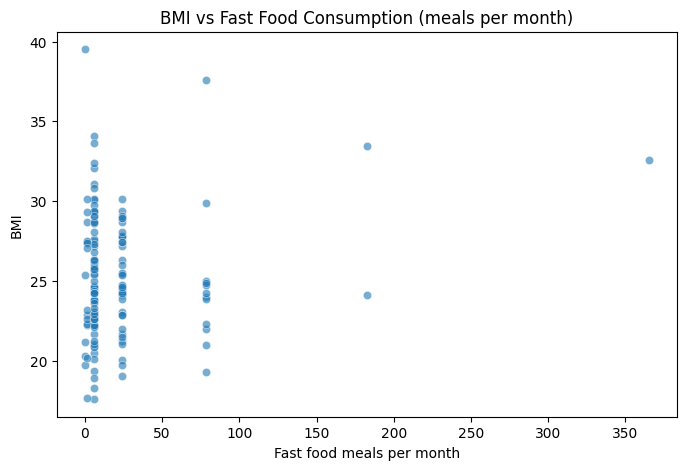

Pearson correlation coefficient between fastfood and BMI: 0.153


In [21]:
## TODO
# BMI vs fast food consumption
plt.figure(figsize=(8,5))
sns.scatterplot(x='fastfood', y='BMI', data=df, alpha=0.6)
plt.title('BMI vs Fast Food Consumption (meals per month)')
plt.xlabel('Fast food meals per month')
plt.ylabel('BMI')
plt.show()

# Correlation
corr = df['fastfood'].corr(df['BMI'])
print(f"Pearson correlation coefficient between fastfood and BMI: {corr:.3f}")

### b) BMI by Gender

- Use boxplots or violin plots to compare BMI distributions between genders.
- Test for significant differences (e.g., t-test or Mann-Whitney U test).

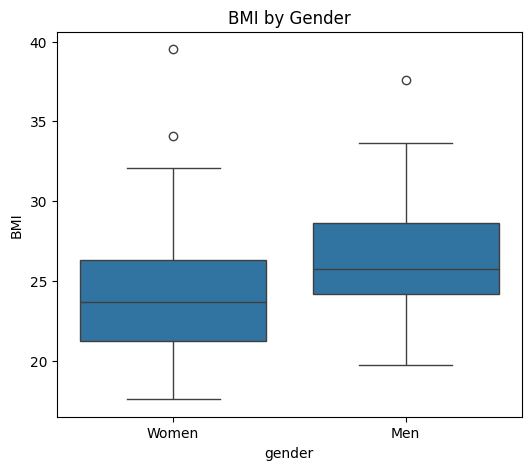

T-test (Welch) results: t = -3.325, p-value = 0.0011
Significant difference at alpha=0.05.


In [22]:
## TODO
# BMI by gender comparison with test
plt.figure(figsize=(6,5))
sns.boxplot(x='gender', y='BMI', data=df)
plt.xticks([0,1], ['Women', 'Men'])
plt.title('BMI by Gender')
plt.ylabel('BMI')
plt.show()

# Test for significant difference (t-test assuming unequal variances)
from scipy.stats import ttest_ind
women_bmi = df[df['gender']==0]['BMI']
men_bmi = df[df['gender']==1]['BMI']
t_stat, p_value = ttest_ind(women_bmi, men_bmi, equal_var=False)
print(f"T-test (Welch) results: t = {t_stat:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Significant difference at alpha=0.05.")
else:
    print("No significant difference.")

### c) BMI by Urbanity

- Visualize BMI across different urbanity categories using boxplots or bar plots.
- Discuss any differences or trends.

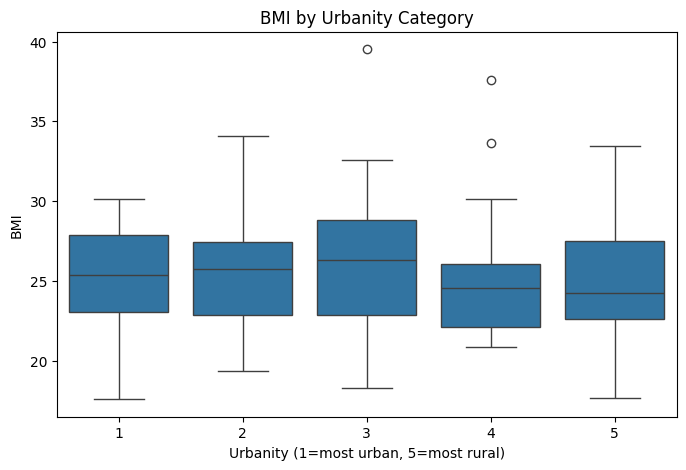

Mean BMI by urbanity:
urbanity
1    25.331508
2    25.339248
3    26.263986
4    25.175240
5    24.773585
Name: BMI, dtype: float64


In [23]:
## TODO
#BMI by urbanity categories
# Assuming urbanity is ordinal: 1=capital, 2=..., 5=rural? 


plt.figure(figsize=(8,5))
sns.boxplot(x='urbanity', y='BMI', data=df)
plt.title('BMI by Urbanity Category')
plt.xlabel('Urbanity (1=most urban, 5=most rural)')
plt.ylabel('BMI')
plt.show()

# Possibly compute mean per group
urban_means = df.groupby('urbanity')['BMI'].mean()
print("Mean BMI by urbanity:")
print(urban_means)

### d) Additional Bivariate Relationships

- Explore other pairs of variables as relevant (e.g., weight vs. height, fast food vs. gender).
- Use appropriate plots and statistics.

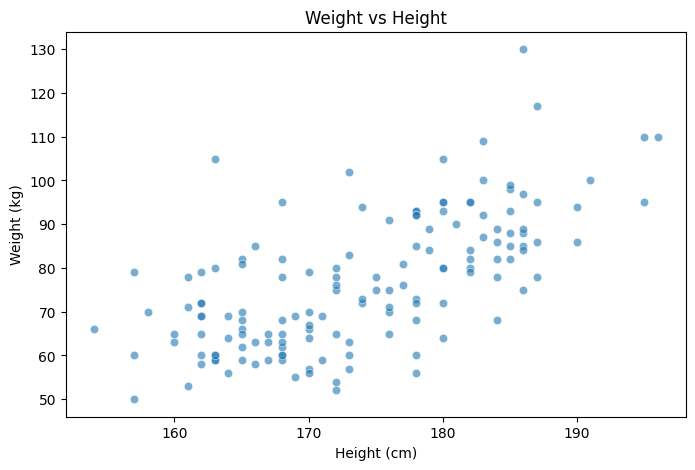

Correlation between height and weight: 0.655


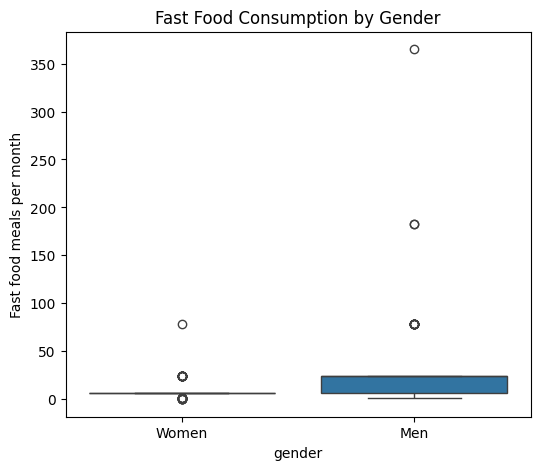

In [24]:
## TODO
# Additional relationships

plt.figure(figsize=(8,5))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
plt.title('Weight vs Height')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

corr_hw = df['height'].corr(df['weight'])
print(f"Correlation between height and weight: {corr_hw:.3f}")

# fast food consumption by gender
plt.figure(figsize=(6,5))
sns.boxplot(x='gender', y='fastfood', data=df)
plt.xticks([0,1], ['Women', 'Men'])
plt.title('Fast Food Consumption by Gender')
plt.ylabel('Fast food meals per month')
plt.show()

## 4. Summary

- Summarize the key findings from your missing value analysis, outlier handling, and bivariate EDA.
- Discuss how these steps improve the quality and reliability of your subsequent analyses.

In [25]:
## TODO
# Summary of findings
print("Key findings:")
print("- No missing values in dataset.")
print("- Outliers exist in BMI and weight but are retained as plausible.")
print("- Weak positive correlation between BMI and fast food consumption.")
print("- Significant difference in BMI between genders (men higher).")
print("- Slight variation in BMI across urbanity categories.")
print("- Height and weight strongly correlated.")

Key findings:
- No missing values in dataset.
- Outliers exist in BMI and weight but are retained as plausible.
- Weak positive correlation between BMI and fast food consumption.
- Significant difference in BMI between genders (men higher).
- Slight variation in BMI across urbanity categories.
- Height and weight strongly correlated.


Happy Coding .... ;) 